# 📊 Correlation Analysis

> **Folder:** `02_Exploratory_Data_Analysis / Correlation_Analysis`  
> **Notebook:** `correlation_analysis.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Compute and compare **Pearson, Spearman, and Kendall** correlation coefficients
- Build and interpret **correlation matrix heatmaps** in multiple styles
- Measure **feature-target correlation** for all variable types
- Apply **Point-Biserial, Phi, and Cramér's V** for mixed variable types
- Detect and visualize **multicollinearity** using correlation and VIF
- Build a complete **automated correlation EDA report**

---

## 📚 Techniques Covered

| # | Technique | Variable Types |
|---|-----------|:--------------:|
| 1 | Pearson Correlation Matrix | Num × Num |
| 2 | Spearman Correlation Matrix | Num × Num |
| 3 | Kendall's Tau Matrix | Num × Num |
| 4 | All-Methods Comparison | Num × Num |
| 5 | Clustered Correlation Heatmap | Num × Num |
| 6 | Feature–Target Correlation Ranking | Num × Target |
| 7 | Point-Biserial Correlation | Num × Binary |
| 8 | Phi Coefficient | Binary × Binary |
| 9 | Cramér's V Heatmap | Cat × Cat |
| 10 | Multicollinearity Detection + VIF | Num × Num |
| 11 | Significance Matrix (p-values) | Num × Num |
| 12 | Automated Correlation EDA Report | All types |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import (
    pearsonr, spearmanr, kendalltau,
    pointbiserialr, chi2_contingency
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Inspect Dataset

In [2]:
np.random.seed(42)
n = 600

edu_levels  = ["High School", "Bachelor's", "Master's", "PhD"]
edu_probs   = [0.25, 0.40, 0.25, 0.10]
education   = np.random.choice(edu_levels, n, p=edu_probs)
edu_salary  = {"High School": 35_000, "Bachelor's": 60_000,
               "Master's": 90_000,    "PhD": 120_000}
base_salary = np.array([edu_salary[e] for e in education])

age         = np.random.randint(22, 65, n)
experience  = np.clip(age - 22 + np.random.randint(-3, 8, n), 0, 40)
salary      = (base_salary + experience * 1500
               + np.random.normal(0, 10_000, n)).clip(20_000, 200_000)
score       = (50 + salary / 5000 + np.random.normal(0, 8, n)).clip(0, 100)
savings     = (salary * 0.15 + np.random.normal(0, 3000, n)).clip(0)
debt        = (salary * 0.25 - experience * 500
               + np.random.normal(0, 5000, n)).clip(0)
income      = np.random.exponential(50_000, n)

df = pd.DataFrame({
    'Age'          : age,
    'Experience'   : experience,
    'Salary'       : salary.astype(int),
    'Score'        : score.round(1),
    'Savings'      : savings.astype(int),
    'Debt'         : debt.astype(int),
    'Income'       : income.astype(int),
    'Num_Products' : np.random.randint(1, 15, n),
    'Education'    : education,
    'City'         : np.random.choice(
                         ['London','Paris','Berlin','Tokyo','Sydney'], n,
                         p=[0.35,0.25,0.20,0.12,0.08]),
    'Gender'       : np.random.choice(['Male','Female'], n, p=[0.50,0.50]),
    'Has_Insurance': np.random.choice([0, 1], n, p=[0.40, 0.60]),
    'Churn'        : np.random.choice([0, 1], n, p=[0.78, 0.22]),
})

num_cols  = ['Age','Experience','Salary','Score','Savings','Debt','Income','Num_Products']
cat_cols  = ['Education','City','Gender']
bin_cols  = ['Has_Insurance','Churn']
target    = 'Churn'
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]

print(f'Shape   : {df.shape}')
print(f'Numeric : {num_cols}')
print(f'Binary  : {bin_cols}')
print(f'Categ.  : {cat_cols}')
df.head()

Shape   : (600, 13)
Numeric : ['Age', 'Experience', 'Salary', 'Score', 'Savings', 'Debt', 'Income', 'Num_Products']
Binary  : ['Has_Insurance', 'Churn']
Categ.  : ['Education', 'City', 'Gender']


,Age,Experience,Salary,Score,Savings,Debt,Income,Num_Products,Education,City,Gender,Has_Insurance,Churn
0,26,2,51115,52.3000,3654,21260,99564,4,Bachelor's,London,Female,0,1
1,39,14,144120,75.1000,22336,30129,18466,13,PhD,Paris,Male,1,1
2,49,33,152191,91.9000,18788,28510,17374,9,Master's,Paris,Female,0,0
3,63,39,125477,72.9000,19945,1623,15462,5,Bachelor's,Paris,Male,1,0
4,43,24,102419,81.7000,12971,17675,20231,14,High School,Paris,Male,1,1


---
## 1️⃣ Pearson Correlation Matrix

> Measures the **linear** relationship between every pair of numerical features.  
> Best for continuous, normally distributed data without significant outliers.
>
> ✅ Standard starting point for any numerical correlation analysis.

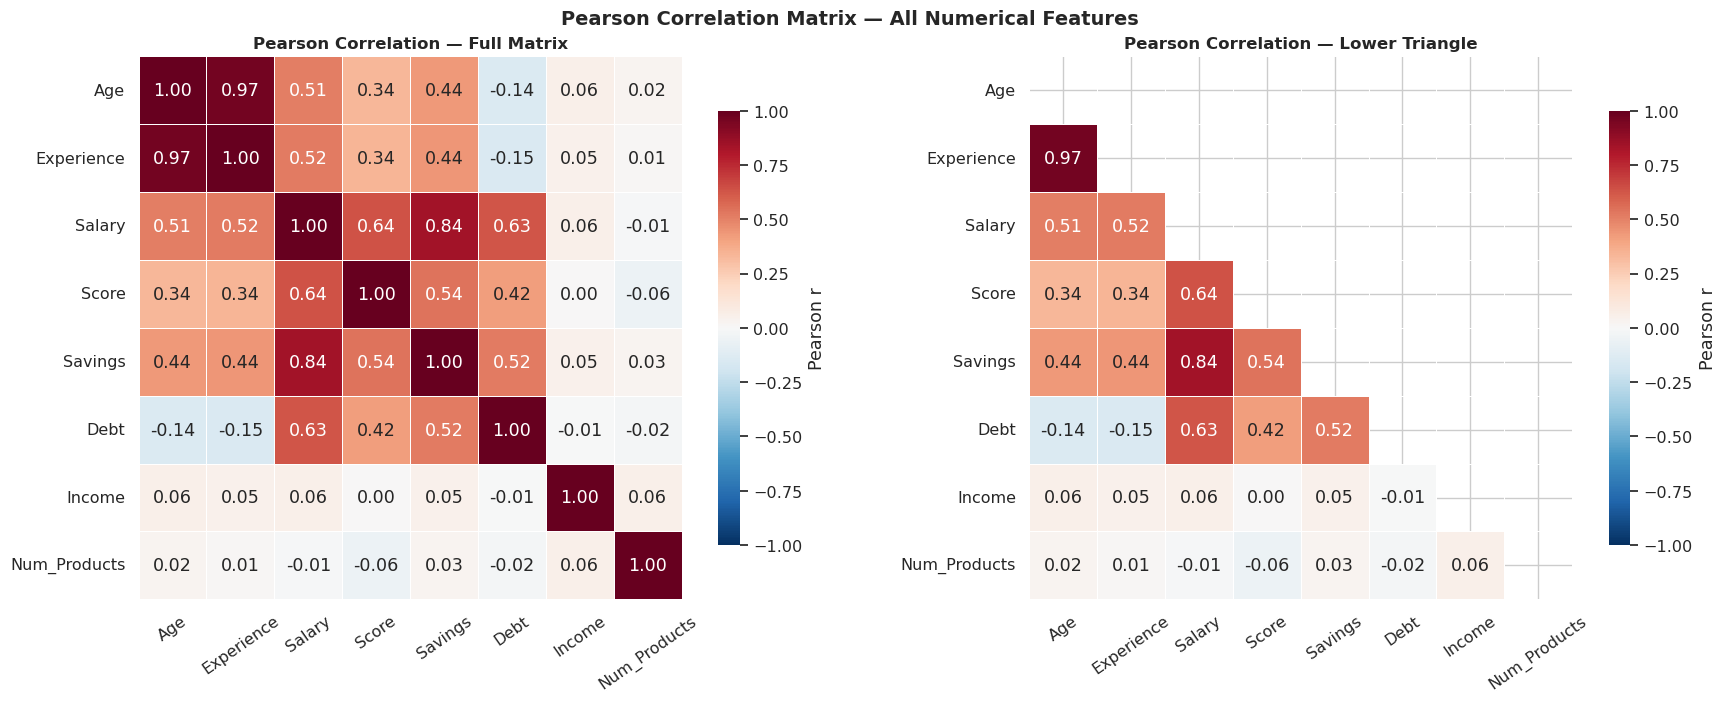


Pearson Correlation Matrix:


,Age,Experience,Salary,Score,Savings,Debt,Income,Num_Products
Age,1.0000,0.9680,0.5150,0.3350,0.4370,-0.1420,0.0560,0.0250
Experience,0.9680,1.0000,0.5170,0.3380,0.4380,-0.1540,0.0500,0.0120
Salary,0.5150,0.5170,1.0000,0.6380,0.8400,0.6280,0.0570,-0.0100
Score,0.3350,0.3380,0.6380,1.0000,0.5430,0.4190,0.0050,-0.0620
Savings,0.4370,0.4380,0.8400,0.5430,1.0000,0.5230,0.0530,0.0270
Debt,-0.1420,-0.1540,0.6280,0.4190,0.5230,1.0000,-0.0050,-0.0180
Income,0.0560,0.0500,0.0570,0.0050,0.0530,-0.0050,1.0000,0.0600
Num_Products,0.0250,0.0120,-0.0100,-0.0620,0.0270,-0.0180,0.0600,1.0000


In [3]:
pearson_corr = df[num_cols].corr(method='pearson')
mask_upper   = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
sns.heatmap(
    pearson_corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=axes[0],
    cbar_kws={'shrink': 0.80, 'label': 'Pearson r'}
)
axes[0].set_title('Pearson Correlation — Full Matrix',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Lower triangle only
sns.heatmap(
    pearson_corr, mask=mask_upper,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=axes[1],
    cbar_kws={'shrink': 0.80, 'label': 'Pearson r'}
)
axes[1].set_title('Pearson Correlation — Lower Triangle',
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Pearson Correlation Matrix — All Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nPearson Correlation Matrix:')
pearson_corr.round(3)

---
## 2️⃣ Spearman Correlation Matrix

> Converts values to ranks first, then applies Pearson to the ranks.  
> Captures **monotonic** relationships — robust to outliers and non-normal data.
>
> ✅ **Spearman − Pearson difference** reveals which pairs are non-linear.

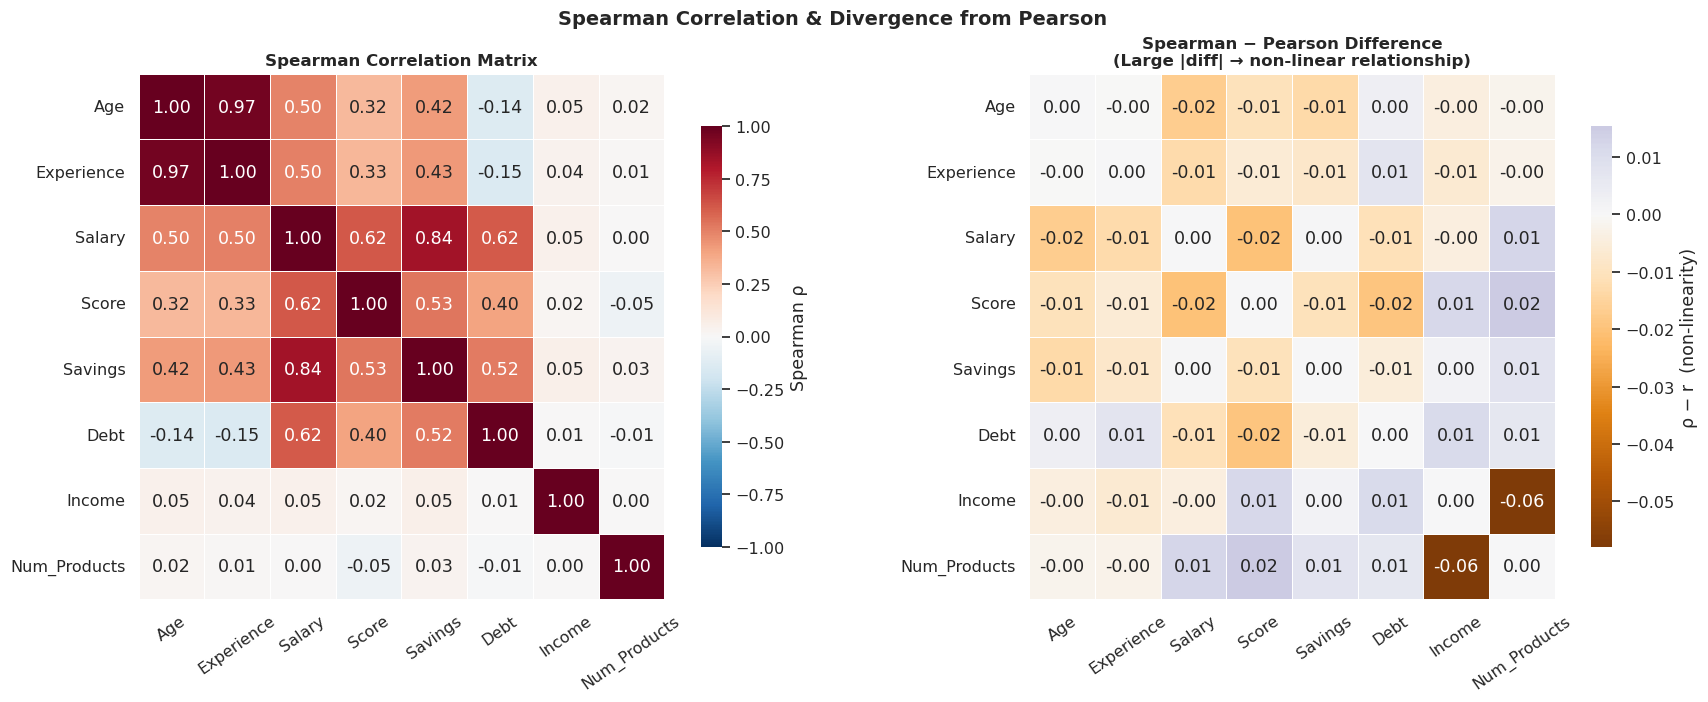

In [4]:
spearman_corr = df[num_cols].corr(method='spearman')
diff_corr     = spearman_corr - pearson_corr  # divergence: non-linearity signal

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    spearman_corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=axes[0],
    cbar_kws={'shrink': 0.80, 'label': 'Spearman ρ'}
)
axes[0].set_title('Spearman Correlation Matrix',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    diff_corr, annot=True, fmt='.2f',
    cmap='PuOr', center=0,
    linewidths=0.5, square=True, ax=axes[1],
    cbar_kws={'shrink': 0.80, 'label': 'ρ − r  (non-linearity)'}
)
axes[1].set_title('Spearman − Pearson Difference\n'
                   '(Large |diff| → non-linear relationship)',
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Spearman Correlation & Divergence from Pearson',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ Kendall's Tau Correlation Matrix

> Measures **concordance** — the proportion of consistently ordered pairs.  
> More robust than Spearman for small samples and tied ranks.
>
> ⚠️ Kendall τ values are typically smaller than Spearman ρ — this is expected.

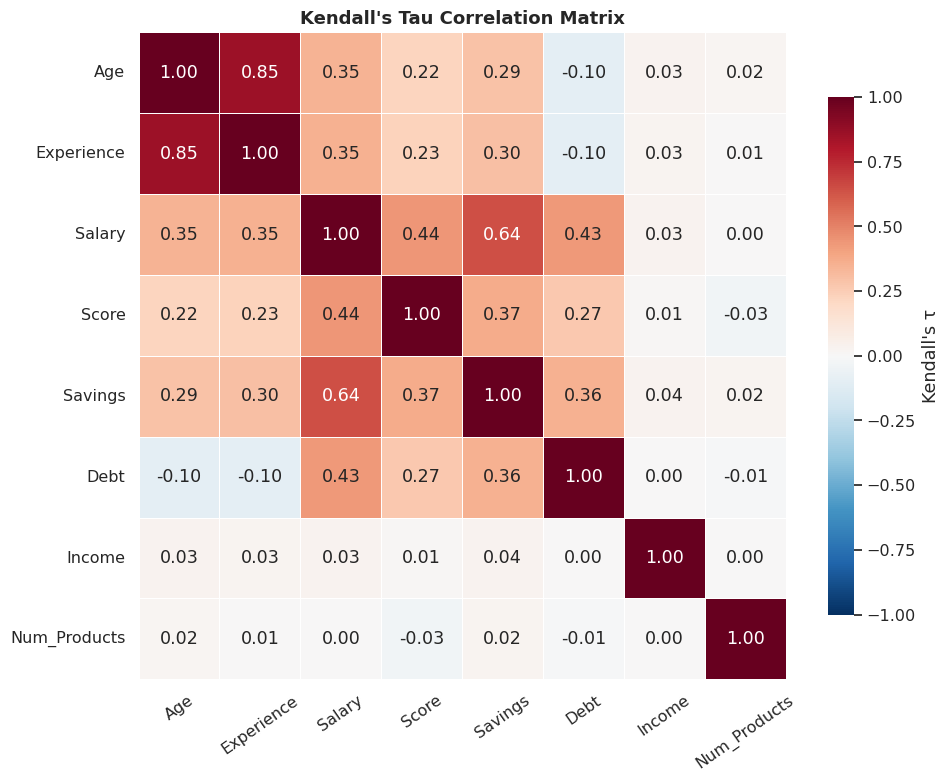

In [5]:
kendall_corr = df[num_cols].corr(method='kendall')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    kendall_corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.80, "label": "Kendall's τ"}
)
ax.set_title("Kendall's Tau Correlation Matrix", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

---
## 4️⃣ Pearson vs Spearman vs Kendall — All-Methods Comparison

> Side-by-side comparison for all unique feature pairs.  
> **Large divergence between Pearson and Spearman** = non-linear relationship.

In [6]:
comparison_rows = []
seen = set()

for col_a in num_cols:
    for col_b in num_cols:
        if col_a == col_b: continue
        key = tuple(sorted([col_a, col_b]))
        if key in seen: continue
        seen.add(key)
        data       = df[[col_a, col_b]].dropna()
        p_r, _     = pearsonr(data[col_a],   data[col_b])
        s_r, _     = spearmanr(data[col_a],  data[col_b])
        k_r, _     = kendalltau(data[col_a], data[col_b])
        divergence = abs(s_r - p_r)
        comparison_rows.append({
            'Feature A'   : col_a,
            'Feature B'   : col_b,
            'Pearson r'   : round(p_r, 4),
            'Spearman ρ'  : round(s_r, 4),
            'Kendall τ'   : round(k_r, 4),
            '|ρ − r|'     : round(divergence, 4),
            'Non-Linear?' : '⚠️ Yes' if divergence > 0.10 else '  No',
            'Best Method' : 'Spearman' if divergence > 0.10 else 'Pearson',
        })

comp_df = (pd.DataFrame(comparison_rows)
             .sort_values('|ρ − r|', ascending=False)
             .reset_index(drop=True))

print('Correlation Comparison — All Pairs (sorted by divergence):')
print(comp_df.to_string(index=False))

Correlation Comparison — All Pairs (sorted by divergence):
 Feature A    Feature B  Pearson r  Spearman ρ  Kendall τ  |ρ − r| Non-Linear? Best Method
    Income Num_Products     0.0596      0.0017     0.0003   0.0579          No     Pearson
    Salary        Score     0.6381      0.6181     0.4404   0.0201          No     Pearson
     Score         Debt     0.4194      0.3999     0.2730   0.0196          No     Pearson
       Age       Salary     0.5150      0.4982     0.3491   0.0168          No     Pearson
     Score Num_Products    -0.0625     -0.0472    -0.0331   0.0153          No     Pearson
       Age      Savings     0.4365      0.4232     0.2946   0.0134          No     Pearson
Experience       Salary     0.5171      0.5040     0.3548   0.0131          No     Pearson
    Salary Num_Products    -0.0102      0.0021     0.0016   0.0123          No     Pearson
     Score       Income     0.0049      0.0167     0.0101   0.0118          No     Pearson
      Debt       Income    -0.0

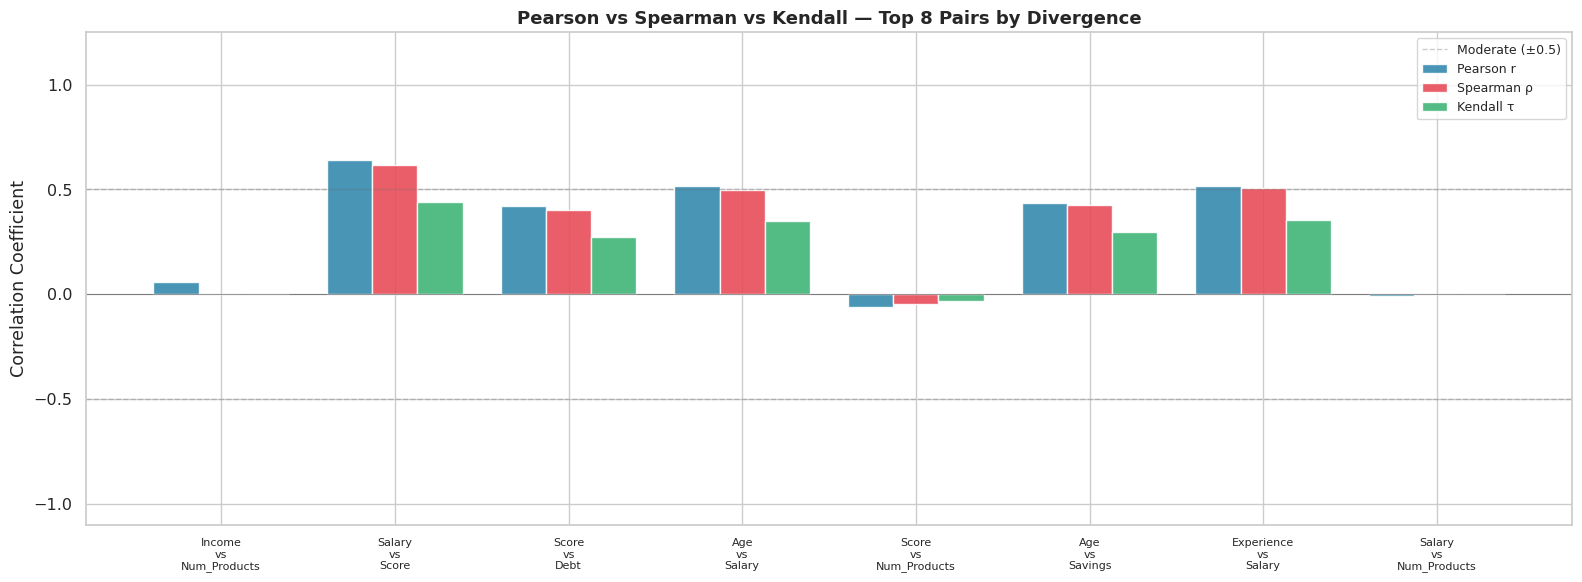

In [7]:
# ── Grouped bar chart: top-8 pairs by divergence ──────────────────────────
top_n    = 8
top_comp = comp_df.head(top_n)
labels   = [f"{r['Feature A']}\nvs\n{r['Feature B']}" for _, r in top_comp.iterrows()]
x        = np.arange(len(top_comp))
w        = 0.26

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, top_comp['Pearson r'],  w, label='Pearson r',
       color=COLORS['primary'],   edgecolor='white', alpha=0.88)
ax.bar(x,     top_comp['Spearman ρ'], w, label='Spearman ρ',
       color=COLORS['secondary'], edgecolor='white', alpha=0.88)
ax.bar(x + w, top_comp['Kendall τ'],  w, label='Kendall τ',
       color=COLORS['accent'],    edgecolor='white', alpha=0.88)
ax.axhline(0,   color='black', linewidth=0.7, alpha=0.4)
ax.axhline(0.5, color='gray',  linewidth=1.0, linestyle='--',
           alpha=0.4, label='Moderate (±0.5)')
ax.axhline(-0.5, color='gray', linewidth=1.0, linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Correlation Coefficient')
ax.set_ylim(-1.1, 1.25)
ax.set_title(f'Pearson vs Spearman vs Kendall — Top {top_n} Pairs by Divergence',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5️⃣ Clustered Correlation Heatmap

> Reorders rows and columns using **hierarchical clustering** —  
> groups of highly correlated features cluster together visually.
>
> ✅ Reveals blocks of correlated features that could be merged or dropped.

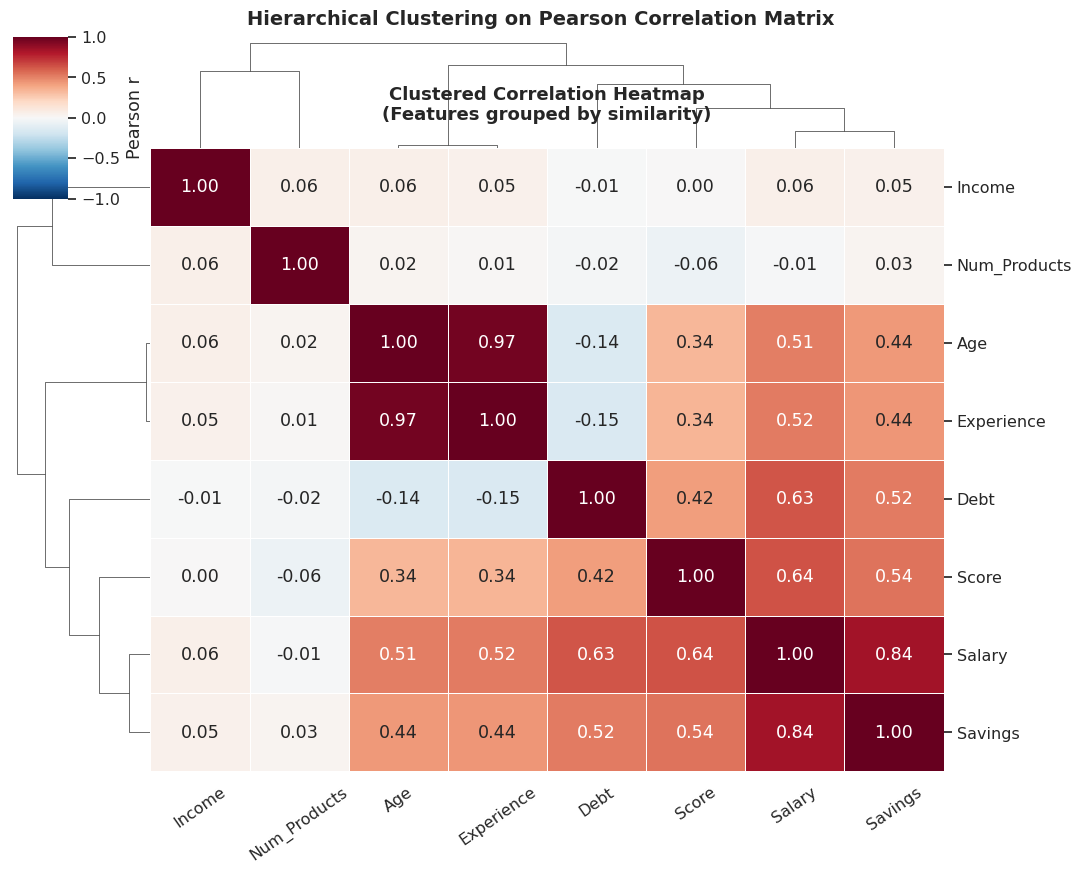


💡 Features close in the dendrogram are highly correlated.
   Consider merging or dropping one from each tight cluster.


In [8]:
g = sns.clustermap(
    pearson_corr,
    method='average', metric='euclidean',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.4,
    figsize=(11, 9),
    cbar_kws={'label': 'Pearson r', 'shrink': 0.6},
    dendrogram_ratio=0.15,
)
g.ax_heatmap.set_title(
    'Clustered Correlation Heatmap\n(Features grouped by similarity)',
    fontsize=13, fontweight='bold', pad=20
)
g.ax_heatmap.tick_params(axis='x', rotation=35)
g.ax_heatmap.tick_params(axis='y', rotation=0)
plt.suptitle('Hierarchical Clustering on Pearson Correlation Matrix',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()
print('\n💡 Features close in the dendrogram are highly correlated.')
print('   Consider merging or dropping one from each tight cluster.')

---
## 6️⃣ Feature–Target Correlation Ranking

> Ranks every numerical feature by its absolute Pearson correlation with the target.  
> An instant **feature importance proxy** before any model is trained.
>
> ✅ High |r| with target = strong candidate to keep.

Feature–Target Correlation ("Churn"):
     Feature  Pearson r  |Pearson r|  Spearman ρ  p-value Significant  Direction   Strength
        Debt     0.0986       0.0986      0.0935   0.0157           ✅ ↑ Positive Negligible
Num_Products    -0.0570       0.0570     -0.0580   0.1635           ❌ ↓ Negative Negligible
      Income    -0.0481       0.0481     -0.0238   0.2397           ❌ ↓ Negative Negligible
     Savings    -0.0465       0.0465     -0.0463   0.2554           ❌ ↓ Negative Negligible
  Experience    -0.0412       0.0412     -0.0404   0.3134           ❌ ↓ Negative Negligible
         Age    -0.0403       0.0403     -0.0412   0.3238           ❌ ↓ Negative Negligible
       Score     0.0342       0.0342      0.0288   0.4028           ❌ ↑ Positive Negligible
      Salary     0.0174       0.0174      0.0122   0.6702           ❌ ↑ Positive Negligible


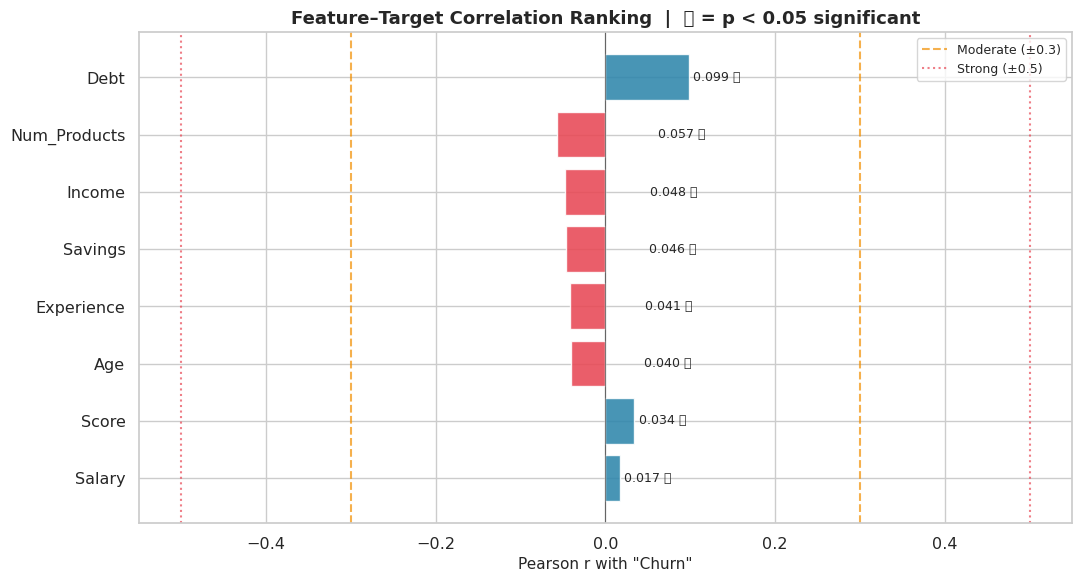

In [9]:
target_rows = []
for col in num_cols:
    r_p, p_p = pearsonr(df[col],  df[target])
    r_s, p_s = spearmanr(df[col], df[target])
    target_rows.append({
        'Feature'    : col,
        'Pearson r'  : round(r_p, 4),
        '|Pearson r|': round(abs(r_p), 4),
        'Spearman ρ' : round(r_s, 4),
        'p-value'    : round(p_p, 4),
        'Significant': '✅' if p_p < 0.05 else '❌',
        'Direction'  : '↑ Positive' if r_p > 0 else '↓ Negative',
        'Strength'   : ('Strong'   if abs(r_p) >= 0.5 else
                        'Moderate' if abs(r_p) >= 0.3 else
                        'Weak'     if abs(r_p) >= 0.1 else 'Negligible'),
    })

target_df = (pd.DataFrame(target_rows)
               .sort_values('|Pearson r|', ascending=False)
               .reset_index(drop=True))
print(f'Feature–Target Correlation ("{target}"):')
print(target_df.to_string(index=False))

# ── Horizontal bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [
    COLORS['primary'] if v >= 0 else COLORS['secondary']
    for v in target_df['Pearson r']
]
bars = ax.barh(target_df['Feature'], target_df['Pearson r'],
               color=bar_colors, edgecolor='white', alpha=0.88)
ax.axvline(0,    color='black',          linewidth=0.8, alpha=0.5)
ax.axvline(0.3,  color=COLORS['warning'],   linewidth=1.5,
           linestyle='--', alpha=0.7, label='Moderate (±0.3)')
ax.axvline(-0.3, color=COLORS['warning'],   linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.axvline(0.5,  color=COLORS['secondary'], linewidth=1.5,
           linestyle=':', alpha=0.7, label='Strong (±0.5)')
ax.axvline(-0.5, color=COLORS['secondary'], linewidth=1.5,
           linestyle=':', alpha=0.7)
for bar, row in zip(bars, target_df.itertuples()):
    v    = row._3
    xpos = v + (0.005 if v >= 0 else -0.005)
    ha   = 'left' if v >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f} {row.Significant}', va='center', ha=ha, fontsize=9)
ax.set_xlabel(f'Pearson r with "{target}"', fontsize=11)
ax.set_title(f'Feature–Target Correlation Ranking  |  '
             f'✅ = p < 0.05 significant',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7️⃣ Point-Biserial Correlation — Continuous vs Binary

> Measures the relationship between a **continuous feature** and a **binary (0/1) variable**.  
> Mathematically equivalent to Pearson applied to one binary and one continuous variable.
>
> ✅ Correct metric for evaluating continuous features against a binary target.

Point-Biserial Correlation — Continuous vs Binary:
  Continuous        Binary    r_pb  |r_pb|  p-value Significant   Strength
        Debt         Churn  0.0986  0.0986   0.0157           ✅ Negligible
Num_Products         Churn -0.0570  0.0570   0.1635           ❌ Negligible
      Income         Churn -0.0481  0.0481   0.2397           ❌ Negligible
     Savings         Churn -0.0465  0.0465   0.2554           ❌ Negligible
  Experience         Churn -0.0412  0.0412   0.3134           ❌ Negligible
         Age         Churn -0.0403  0.0403   0.3238           ❌ Negligible
       Score         Churn  0.0342  0.0342   0.4028           ❌ Negligible
      Salary         Churn  0.0174  0.0174   0.6702           ❌ Negligible
         Age Has_Insurance  0.0689  0.0689   0.0916           ❌ Negligible
  Experience Has_Insurance  0.0659  0.0659   0.1070           ❌ Negligible
Num_Products Has_Insurance  0.0572  0.0572   0.1615           ❌ Negligible
      Salary Has_Insurance  0.0466  0.0466   0.25

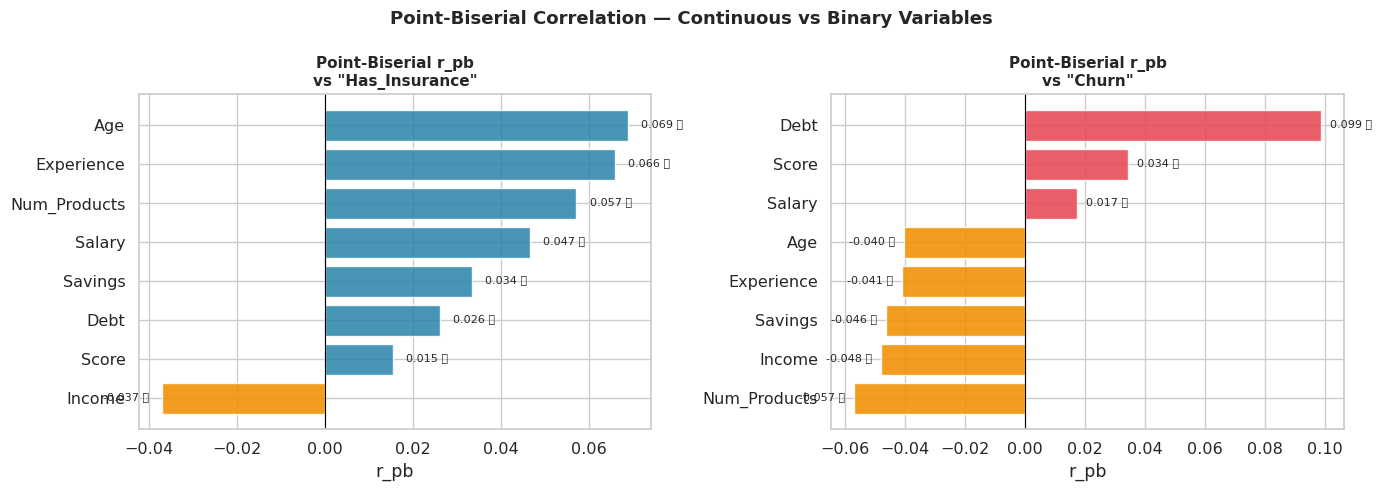

In [10]:
pb_rows = []
for col in num_cols:
    for bin_col in bin_cols:
        r, p = pointbiserialr(df[col], df[bin_col])
        pb_rows.append({
            'Continuous'  : col,
            'Binary'      : bin_col,
            'r_pb'        : round(r, 4),
            '|r_pb|'      : round(abs(r), 4),
            'p-value'     : round(p, 4),
            'Significant' : '✅' if p < 0.05 else '❌',
            'Strength'    : ('Strong'   if abs(r) >= 0.5 else
                             'Moderate' if abs(r) >= 0.3 else
                             'Weak'     if abs(r) >= 0.1 else 'Negligible'),
        })

pb_df = (pd.DataFrame(pb_rows)
           .sort_values(['Binary','|r_pb|'], ascending=[True, False])
           .reset_index(drop=True))
print('Point-Biserial Correlation — Continuous vs Binary:')
print(pb_df.to_string(index=False))

# ── Faceted bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(bin_cols), figsize=(14, 5))
for ax, bin_col, color in zip(axes, bin_cols,
                               [COLORS['primary'], COLORS['secondary']]):
    sub     = pb_df[pb_df['Binary'] == bin_col].sort_values('r_pb')
    colors_ = [color if v >= 0 else COLORS['warning'] for v in sub['r_pb']]
    bars    = ax.barh(sub['Continuous'], sub['r_pb'],
                      color=colors_, edgecolor='white', alpha=0.88)
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val, sig in zip(bars, sub['r_pb'], sub['Significant']):
        xpos = bar.get_width() + (0.003 if val >= 0 else -0.003)
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f} {sig}', va='center', ha=ha, fontsize=8)
    ax.set_title(f'Point-Biserial r_pb\nvs "{bin_col}"',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('r_pb')
plt.suptitle('Point-Biserial Correlation — Continuous vs Binary Variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Phi Coefficient — Binary vs Binary

> Measures association between **two binary (0/1) variables**.  
> Identical to Pearson r applied to two dichotomous variables.
>
> ✅ Standard measure for binary feature co-occurrence and target association.

Phi Coefficient — Binary vs Binary:
     Binary A      Binary B  Phi (φ)    |φ|  p-value Significant Association
Has_Insurance Has_Insurance   1.0000 1.0000   0.0000           ✅      Strong
Has_Insurance         Churn  -0.0056 0.0056   0.8903           ❌  Negligible
        Churn         Churn   1.0000 1.0000   0.0000           ✅      Strong


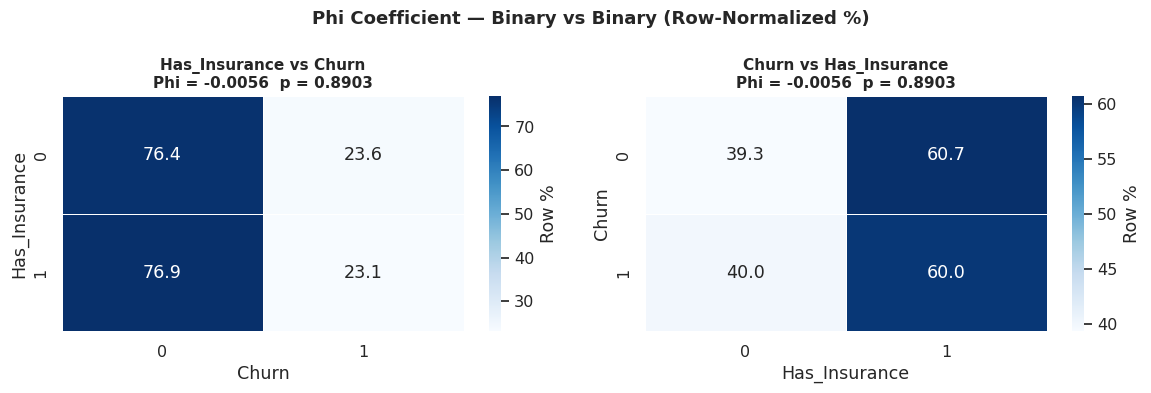

In [11]:
def phi_coefficient(x, y):
    r, p = pearsonr(x, y)
    return round(r, 4), round(p, 4)

phi_rows = []
for i, col_a in enumerate(bin_cols):
    for col_b in bin_cols[i:]:
        r, p = phi_coefficient(df[col_a], df[col_b])
        phi_rows.append({
            'Binary A'   : col_a,
            'Binary B'   : col_b,
            'Phi (φ)'    : r,
            '|φ|'        : abs(r),
            'p-value'    : p,
            'Significant': '✅' if p < 0.05 else '❌',
            'Association': ('Strong'   if abs(r) >= 0.5 else
                            'Moderate' if abs(r) >= 0.3 else
                            'Weak'     if abs(r) >= 0.1 else 'Negligible'),
        })

phi_df = pd.DataFrame(phi_rows)
print('Phi Coefficient — Binary vs Binary:')
print(phi_df.to_string(index=False))

# ── Contingency table heatmaps ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (a, b) in zip(axes, [('Has_Insurance','Churn'), ('Churn','Has_Insurance')]):
    ct   = pd.crosstab(df[a], df[b], normalize='index') * 100
    r, p = phi_coefficient(df[a], df[b])
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Row %'})
    ax.set_title(f'{a} vs {b}\nPhi = {r:.4f}  p = {p:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(b); ax.set_ylabel(a)
plt.suptitle('Phi Coefficient — Binary vs Binary (Row-Normalized %)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Cramér's V — Categorical vs Categorical

> Extension of Phi to **k×k contingency tables** via Chi-Square.  
> Scale-invariant measure of categorical association (0 = none, 1 = perfect).
>
> ✅ Standard correlation measure when both variables are categorical.

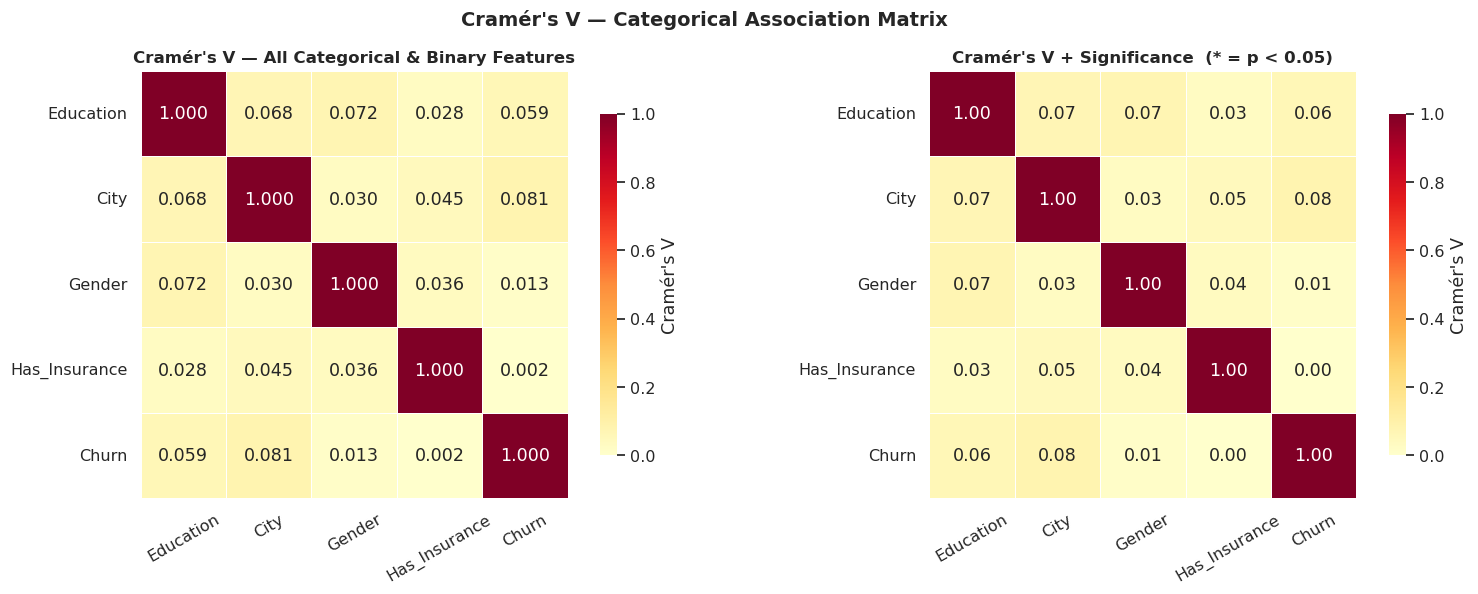

Cramér's V: 0.0–0.1=Negligible | 0.1–0.3=Weak | 0.3–0.5=Moderate | 0.5+=Strong


In [12]:
def cramers_v(x, y):
    ct             = pd.crosstab(x, y)
    chi2, p, _, _  = chi2_contingency(ct)
    n              = ct.sum().sum()
    r, c           = ct.shape
    v              = np.sqrt(chi2 / (n * (min(r, c) - 1)))
    return round(v, 4), round(p, 4)

all_cat   = cat_cols + bin_cols
v_matrix  = pd.DataFrame(index=all_cat, columns=all_cat, dtype=float)
p_matrix  = pd.DataFrame(index=all_cat, columns=all_cat, dtype=float)

for col_a in all_cat:
    for col_b in all_cat:
        if col_a == col_b:
            v_matrix.loc[col_a, col_b] = 1.0
            p_matrix.loc[col_a, col_b] = 0.0
        else:
            v, p = cramers_v(df[col_a].astype(str), df[col_b].astype(str))
            v_matrix.loc[col_a, col_b] = v
            p_matrix.loc[col_a, col_b] = p

v_matrix = v_matrix.astype(float)
p_matrix = p_matrix.astype(float)

# ── Cramér's V heatmap with significance ─────────────────────────────────
annot_arr = []
for i, row in enumerate(all_cat):
    row_a = []
    for j, col in enumerate(all_cat):
        v_val = v_matrix.loc[row, col]
        p_val = p_matrix.loc[row, col]
        star  = '*' if p_val < 0.05 and i != j else ''
        row_a.append(f'{v_val:.2f}{star}')
    annot_arr.append(row_a)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    v_matrix, annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, square=True, ax=axes[0],
    cbar_kws={'shrink': 0.80, "label": "Cramér's V"}
)
axes[0].set_title("Cramér's V — All Categorical & Binary Features",
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    v_matrix, annot=np.array(annot_arr), fmt='',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, square=True, ax=axes[1],
    cbar_kws={'shrink': 0.80, "label": "Cramér's V"}
)
axes[1].set_title("Cramér's V + Significance  (* = p < 0.05)",
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle("Cramér's V — Categorical Association Matrix",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Cramér's V: 0.0–0.1=Negligible | 0.1–0.3=Weak | 0.3–0.5=Moderate | 0.5+=Strong")

---
## 🔟 Multicollinearity Detection + VIF

> **Step 1** — Correlation matrix flags highly correlated pairs (|r| > 0.60).  
> **Step 2** — VIF confirms which features have inflated variance from collinearity.
>
> ✅ Use both together — correlation catches pairs; VIF catches group-level collinearity.

🔍 STEP 1 — High Correlation Pairs (|r| > 0.60):
───────────────────────────────────────────────────────
  Age             × Experience       r = +0.968  🔴 Very High
  Salary          × Score            r = +0.638  🟡 High
  Salary          × Savings          r = +0.840  🔴 Very High
  Salary          × Debt             r = +0.628  🟡 High

🔍 STEP 2 — VIF Analysis:
───────────────────────────────────────────────────────
     Feature     VIF   Severity       Action
  Experience 17.1300   🔴 Severe Drop / Merge
         Age 16.0900   🔴 Severe Drop / Merge
      Salary  7.5200 🟡 Moderate  Investigate
        Debt  3.4500      🟢 Low         Keep
     Savings  3.4100      🟢 Low         Keep
       Score  1.7000      🟢 Low         Keep
Num_Products  1.0200      🟢 Low         Keep
      Income  1.0100      🟢 Low         Keep


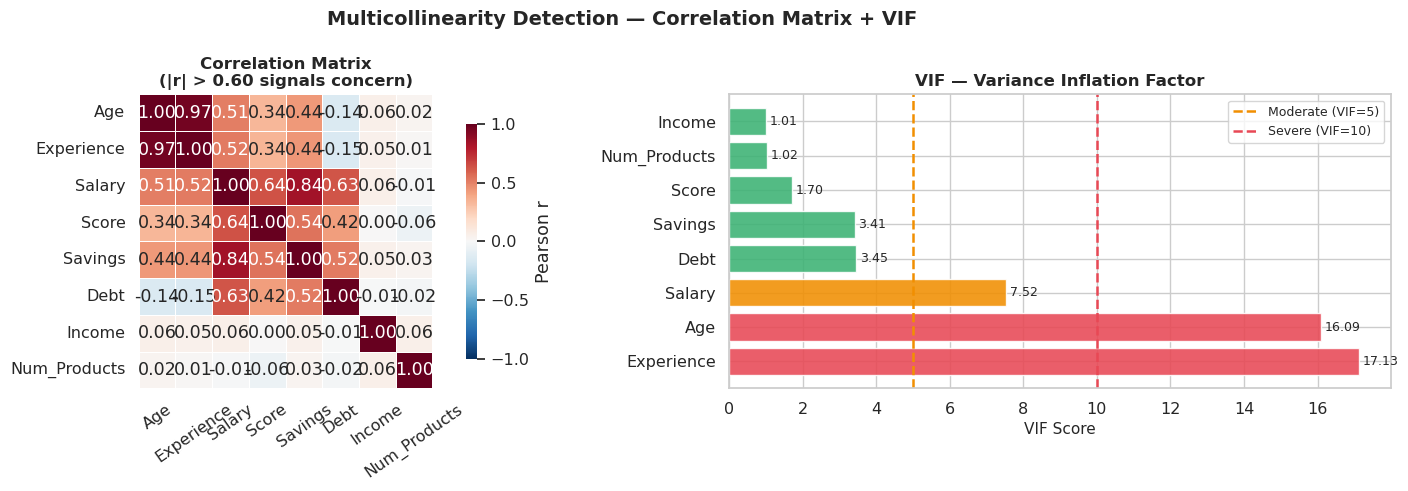

In [13]:
# ── Step 1: High pairwise correlations ────────────────────────────────────
print('🔍 STEP 1 — High Correlation Pairs (|r| > 0.60):')
print('─' * 55)
seen = set()
found_any = False
for col_a in num_cols:
    for col_b in num_cols:
        if col_a == col_b: continue
        key = tuple(sorted([col_a, col_b]))
        if key in seen: continue
        r = pearson_corr.loc[col_a, col_b]
        if abs(r) > 0.60:
            flag = '🔴 Very High' if abs(r) > 0.80 else '🟡 High'
            print(f'  {col_a:15s} × {col_b:15s}  r = {r:+.3f}  {flag}')
            found_any = True
        seen.add(key)
if not found_any:
    print('  No high correlation pairs found ✅')

# ── Step 2: VIF ────────────────────────────────────────────────────────────
print('\n🔍 STEP 2 — VIF Analysis:')
print('─' * 55)
X_vif_sc = pd.DataFrame(
    StandardScaler().fit_transform(df[num_cols]), columns=num_cols
)
vif_df = pd.DataFrame({
    'Feature' : num_cols,
    'VIF'     : [variance_inflation_factor(X_vif_sc.values, i)
                 for i in range(len(num_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: '🔴 Severe'   if v > 10 else
              ('🟡 Moderate' if v > 5  else '🟢 Low')
)
vif_df['Action'] = vif_df['VIF'].apply(
    lambda v: 'Drop / Merge' if v > 10 else
              ('Investigate' if v > 5  else 'Keep')
)
print(vif_df.round(2).to_string(index=False))

# ── Combined visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pearson_corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=axes[0],
    cbar_kws={'shrink': 0.80, 'label': 'Pearson r'}
)
axes[0].set_title('Correlation Matrix\n(|r| > 0.60 signals concern)',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

vif_colors = [
    COLORS['secondary'] if v > 10 else
    COLORS['warning']   if v > 5  else
    COLORS['accent'] for v in vif_df['VIF']
]
bars = axes[1].barh(vif_df['Feature'], vif_df['VIF'],
                    color=vif_colors, edgecolor='white', alpha=0.88)
axes[1].axvline(5,  color=COLORS['warning'],   linewidth=1.8,
                linestyle='--', label='Moderate (VIF=5)')
axes[1].axvline(10, color=COLORS['secondary'], linewidth=1.8,
                linestyle='--', label='Severe (VIF=10)')
for bar, val in zip(bars, vif_df['VIF']):
    axes[1].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[1].set_xlabel('VIF Score', fontsize=11)
axes[1].set_title('VIF — Variance Inflation Factor',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Multicollinearity Detection — Correlation Matrix + VIF',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Correlation Significance Matrix

> Overlays **p-value significance markers** on the correlation heatmap.  
> *** p<0.001   ** p<0.01   * p<0.05
>
> ✅ Never trust a correlation without checking its p-value — especially in small samples.

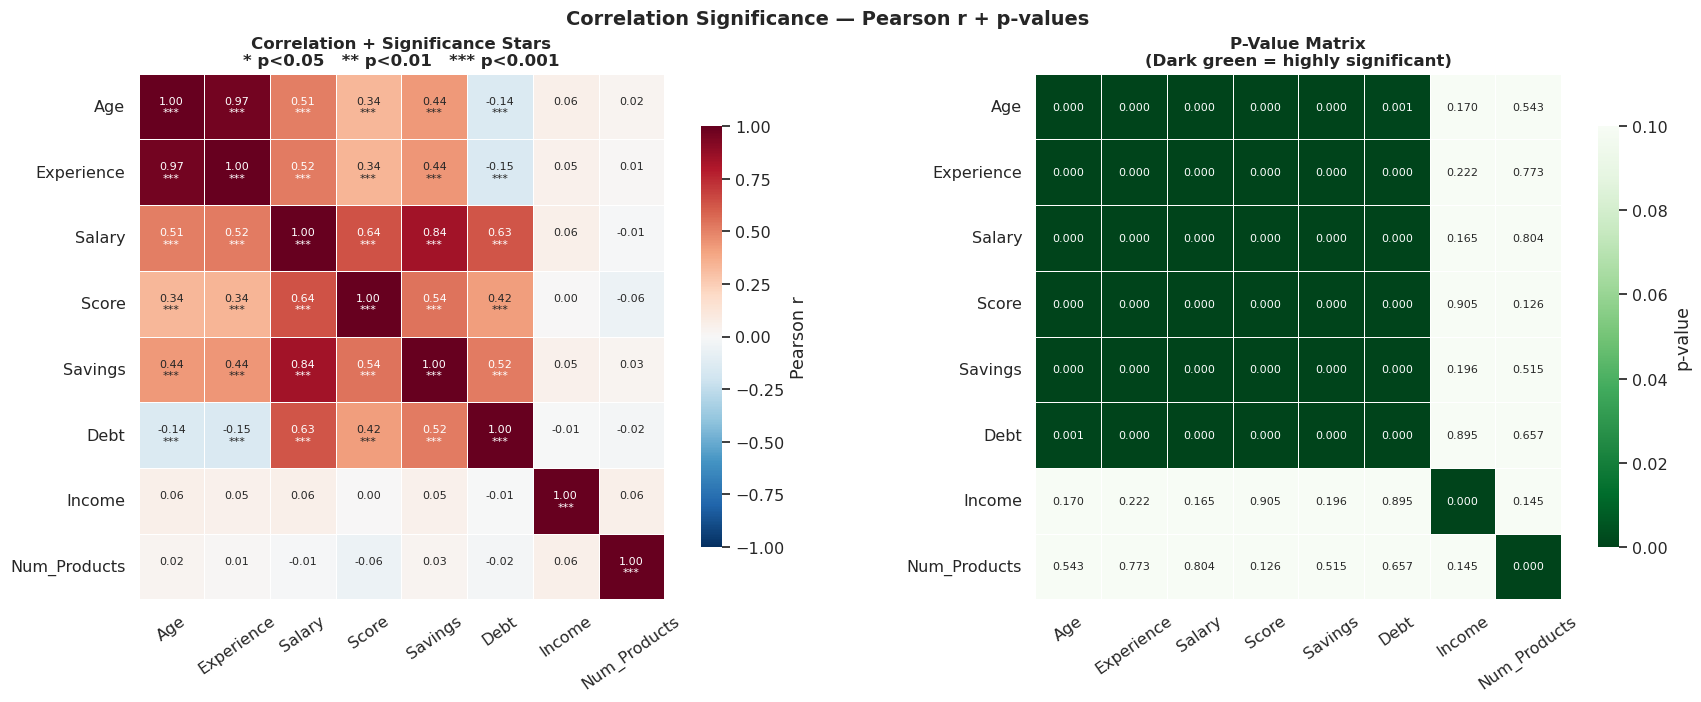

In [14]:
# Build p-value matrix
p_val_matrix = pd.DataFrame(index=num_cols, columns=num_cols, dtype=float)
for col_a in num_cols:
    for col_b in num_cols:
        if col_a == col_b:
            p_val_matrix.loc[col_a, col_b] = 0.0
        else:
            _, p = pearsonr(df[col_a], df[col_b])
            p_val_matrix.loc[col_a, col_b] = round(p, 4)
p_val_matrix = p_val_matrix.astype(float)

# Annotation: r value + significance stars
annot_sig = []
for row in num_cols:
    row_a = []
    for col in num_cols:
        r_v = pearson_corr.loc[row, col]
        p_v = p_val_matrix.loc[row, col]
        stars = ('***' if p_v < 0.001 else
                 '**'  if p_v < 0.01  else
                 '*'   if p_v < 0.05  else '')
        row_a.append(f'{r_v:.2f}\n{stars}')
    annot_sig.append(row_a)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson + significance stars
sns.heatmap(
    pearson_corr, annot=np.array(annot_sig), fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=axes[0],
    cbar_kws={'shrink': 0.80, 'label': 'Pearson r'},
    annot_kws={'size': 8}
)
axes[0].set_title('Correlation + Significance Stars\n'
                   '* p<0.05   ** p<0.01   *** p<0.001',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# P-value heatmap
sns.heatmap(
    p_val_matrix, annot=True, fmt='.3f',
    cmap='Greens_r', vmin=0, vmax=0.10,
    linewidths=0.5, square=True, ax=axes[1],
    cbar_kws={'shrink': 0.80, 'label': 'p-value'},
    annot_kws={'size': 8}
)
axes[1].set_title('P-Value Matrix\n(Dark green = highly significant)',
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Correlation Significance — Pearson r + p-values',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 12. Automated Correlation EDA Report

In [15]:
def correlation_eda_report(df, num_cols, cat_cols, bin_cols, target):
    """
    Generates a 5-section automated correlation EDA report.
    Sections:
      1. Pearson feature-target ranking
      2. Point-biserial (continuous vs binary target)
      3. High pairwise feature correlations
      4. VIF multicollinearity scores
      5. Cramér's V (categorical vs target)
    """
    sep = '=' * 68
    sub = '─' * 58
    print(sep)
    print('  📋  AUTOMATED CORRELATION EDA REPORT')
    print(sep)

    # Section 1 ──────────────────────────────────────────────────────────
    print('\n📌 SECTION 1 — Pearson Feature Correlation with Target')
    print(sub)
    s1_rows = []
    for col in num_cols:
        r, p = pearsonr(df[col], df[target])
        s1_rows.append({
            'Feature'    : col,
            'Pearson r'  : round(r, 4),
            '|r|'        : round(abs(r), 4),
            'p-value'    : round(p, 4),
            'Significant': '✅' if p < 0.05 else '❌',
            'Strength'   : ('Strong'   if abs(r) >= 0.5 else
                            'Moderate' if abs(r) >= 0.3 else
                            'Weak'     if abs(r) >= 0.1 else 'Negligible'),
            'Keep?'      : '✅ Yes' if abs(r) >= 0.1 and p < 0.05
                           else '❌ Review',
        })
    s1 = (pd.DataFrame(s1_rows)
            .sort_values('|r|', ascending=False))
    print(s1.to_string(index=False))

    # Section 2 ──────────────────────────────────────────────────────────
    print('\n📌 SECTION 2 — Point-Biserial (Continuous vs Binary Target)')
    print(sub)
    s2_rows = []
    for col in num_cols:
        r, p = pointbiserialr(df[col], df[target])
        s2_rows.append({
            'Feature': col, 'r_pb': round(r, 4),
            '|r_pb|' : round(abs(r), 4),
            'p-value': round(p, 4),
            'Sig'    : '✅' if p < 0.05 else '❌',
        })
    s2 = (pd.DataFrame(s2_rows)
            .sort_values('|r_pb|', ascending=False))
    print(s2.to_string(index=False))

    # Section 3 ──────────────────────────────────────────────────────────
    print('\n📌 SECTION 3 — High Pairwise Feature Correlations (|r| > 0.60)')
    print(sub)
    corr_mat  = df[num_cols].corr(method='pearson')
    seen      = set()
    found_any = False
    for a in num_cols:
        for b in num_cols:
            if a == b: continue
            key = tuple(sorted([a, b]))
            if key in seen: continue
            r_val = corr_mat.loc[a, b]
            if abs(r_val) > 0.60:
                lvl = '🔴 Very High' if abs(r_val) > 0.80 else '🟡 High'
                print(f'  {a:15s} × {b:15s}  r = {r_val:+.3f}  {lvl}')
                found_any = True
            seen.add(key)
    if not found_any:
        print('  No high pairwise correlations (|r| ≤ 0.60) ✅')

    # Section 4 ──────────────────────────────────────────────────────────
    print('\n📌 SECTION 4 — VIF Multicollinearity Scores')
    print(sub)
    X_sc = pd.DataFrame(
        StandardScaler().fit_transform(df[num_cols]), columns=num_cols
    )
    vif_rpt = pd.DataFrame({
        'Feature': num_cols,
        'VIF'    : [variance_inflation_factor(X_sc.values, i)
                    for i in range(len(num_cols))],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    vif_rpt['Status'] = vif_rpt['VIF'].apply(
        lambda v: '🔴 Drop/Merge' if v > 10 else
                  ('🟡 Investigate' if v > 5 else '🟢 OK')
    )
    print(vif_rpt.round(2).to_string(index=False))

    # Section 5 ──────────────────────────────────────────────────────────
    print("\n📌 SECTION 5 — Cramér's V (Categorical Features vs Target)")
    print(sub)
    s5_rows = []
    for col in cat_cols + bin_cols:
        if col == target: continue
        v, p = cramers_v(df[col].astype(str), df[target].astype(str))
        s5_rows.append({
            'Feature'    : col,
            "Cramér's V" : v,
            'p-value'    : p,
            'Significant': '✅' if p < 0.05 else '❌',
            'Association': ('Strong'   if v >= 0.5 else
                            'Moderate' if v >= 0.3 else
                            'Weak'     if v >= 0.1 else 'Negligible'),
        })
    s5 = (pd.DataFrame(s5_rows)
            .sort_values("Cramér's V", ascending=False))
    print(s5.to_string(index=False))

    print('\n' + sep)
    print('  ✅ Correlation EDA Report Complete')
    print(sep)


correlation_eda_report(df, num_cols, cat_cols, bin_cols, target)

  📋  AUTOMATED CORRELATION EDA REPORT

📌 SECTION 1 — Pearson Feature Correlation with Target
──────────────────────────────────────────────────────────
     Feature  Pearson r    |r|  p-value Significant   Strength    Keep?
        Debt     0.0986 0.0986   0.0157           ✅ Negligible ❌ Review
Num_Products    -0.0570 0.0570   0.1635           ❌ Negligible ❌ Review
      Income    -0.0481 0.0481   0.2397           ❌ Negligible ❌ Review
     Savings    -0.0465 0.0465   0.2554           ❌ Negligible ❌ Review
  Experience    -0.0412 0.0412   0.3134           ❌ Negligible ❌ Review
         Age    -0.0403 0.0403   0.3238           ❌ Negligible ❌ Review
       Score     0.0342 0.0342   0.4028           ❌ Negligible ❌ Review
      Salary     0.0174 0.0174   0.6702           ❌ Negligible ❌ Review

📌 SECTION 2 — Point-Biserial (Continuous vs Binary Target)
──────────────────────────────────────────────────────────
     Feature    r_pb  |r_pb|  p-value Sig
        Debt  0.0986  0.0986   0.0157  

---
## ✅ 13. Summary & Best Practices

| Method | Variable Types | Range | When to Use |
|--------|:-------------:|:-----:|-------------|
| **Pearson r** | Num × Num | −1 to +1 | Linear, normally distributed, no outliers |
| **Spearman ρ** | Num × Num | −1 to +1 | Monotonic, skewed, ordinal, outliers present |
| **Kendall τ** | Num × Num | −1 to +1 | Small samples, tied ranks |
| **Point-Biserial** | Num × Binary | −1 to +1 | Continuous vs 0/1 target |
| **Phi φ** | Binary × Binary | −1 to +1 | Two binary variables |
| **Cramér's V** | Cat × Cat | 0 to +1 | Any categorical size |
| **VIF** | Num × Num | ≥ 1 | Regression multicollinearity |

### 🔑 Golden Rules

1. **Always plot before computing** — a scatter reveals non-linear patterns even when r ≈ 0
2. **Use Spearman when Pearson and Spearman diverge** — signals non-linearity
3. **Always report both r AND p-value** — r = 0.05 can be significant at n = 10,000
4. **Statistical significance ≠ practical significance** — magnitude matters too
5. **Correlation NEVER implies causation** — always verify with domain knowledge
6. **VIF > 10 → drop or regularize** — multicollinearity breaks linear model interpretation
7. **Use Cramér's V for categorical** — chi-square alone is not a comparable measure
8. **Clustered heatmap reveals groups** — features in same cluster carry redundant info
9. **Never compute on full data before split** — that is data leakage
10. **Check both sign and magnitude** — negative r is as informative as positive

---

## 🔗 Next Steps

- ➡️ `03_Supervised_Learning/` — Use correlation rankings to prioritize features
- ➡️ `06_Feature_Selection/` — Filter methods use correlation to drop redundant features
- ➡️ `07_Hyperparameter_Tuning/` — Ridge/Lasso handle multicollinear features via regularization
- ➡️ `04_Unsupervised_Learning/PCA/` — PCA decorrelates features by design
- ➡️ `05_Model_Evaluation/` — Evaluate models built on well-selected, non-collinear features